In [5]:
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools import WikipediaQueryRun

In [6]:
from langchain_community.utilities import ArxivAPIWrapper
from langchain_community.tools import ArxivQueryRun

import arxiv as arxiv_package
arxiv_package.Client.query_url_format = "https://export.arxiv.org/api/query?{}"

api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv,description="Query arxiv papers")
print(arxiv.name)

arxiv


In [7]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [8]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


In [9]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [10]:
#tavily search tool

from langchain_community.tools.tavily_search import TavilySearchResults

tavily=TavilySearchResults()

C:\Users\Kavitha\AppData\Local\Temp\ipykernel_590288\2140773867.py:5: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily=TavilySearchResults()


In [11]:
tavily.invoke("provide me recent news?")

[{'title': 'Associated Press News: Breaking News | Latest News Today',
  'url': 'https://apnews.com',
  'content': '1.   ### Peek inside Georgia’s record-setting sea turtle nesting season\n\n     \n2.   ### Margaret Hamilton, who led a software team for NASA’s Apollo program, dies at 90\n\n     \n3.   ### Strawberry farmer hopes steam holds the key to healthy soil and a better crop\n\n     \n\n\n\n### Caregivers need to take care of themselves, too\n\n1.   ### Amazon’s delivery box: a symbol of instant gratification and convenience\n\n     \n2.   ### Rain gardens help handle today’s downpours. And they can be beautiful too\n\n     \n3.   ### The enduring popularity of Elvis Presley’s Graceland is a monument to his legacy\n\n     \n\n\n\n### What to know about Trump Accounts and automatic enrollment\n\n13\n\n1.   ### US futures are rising as crude prices retreat from recent gains [...] 2.   ### OpenAI fires 3 safety researchers in dispute over AI risks\n\n     \n3.   ### China and EU tr

In [12]:
## combine all tools

tools=[arxiv,wiki,tavily]

In [13]:
# initialize the LLM model
from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen/qwen3.8-27b")

In [14]:
llm.invoke("what is AI?")

AIMessage(content='**AI**, or **Artificial Intelligence**, is a branch of computer science focused on creating systems capable of performing tasks that typically require human intelligence. These tasks include learning, reasoning, problem-solving, perception, and language understanding.\n\n### Key Concepts:\n1. **Machine Learning (ML)**: A subset of AI where algorithms learn patterns from data to make predictions or decisions without being explicitly programmed for every scenario.\n2. **Deep Learning**: A further subset of ML using neural networks with many layers to model complex patterns, often used in image recognition, speech processing, and natural language processing.\n3. **Narrow AI (Weak AI)**: AI specialized for a specific task (e.g., chess engines, recommendation systems). This is the type of AI we have today.\n4. **General AI (Strong AI)**: Hypothetical AI that can perform any intellectual task a human can, with full reasoning and adaptability. This does not yet exist.\n\n##

In [15]:
llm_with_tools=llm.bind_tools(tools=tools)

In [16]:
# execute this call

llm_with_tools.invoke("what is latest research on quantun computing?")

AIMessage(content="I'll search for the latest research on quantum computing.\n\n", additional_kwargs={'tool_calls': [{'id': 'vhm5tmcep', 'function': {'arguments': '{"query":"latest research breakthroughs quantum computing 2025"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}, {'id': 'zzme2y29m', 'function': {'arguments': '{"query":"quantum computing recent advances 2025"}', 'name': 'arxiv'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 86, 'prompt_tokens': 479, 'total_tokens': 565, 'completion_time': 0.249155264, 'completion_tokens_details': None, 'prompt_time': 0.037184339, 'prompt_tokens_details': None, 'queue_time': 0.0473687, 'total_time': 0.286339603}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_21e59ac2de', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a120d5-6ecf-7203-862f-24d9ded15e50-0', tool_calls=[{'name': 'tavily_search_results_json', 'arg

In [17]:
# state schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage ##human or AI
from typing import Annotated ##labelling
from langgraph.graph.message import add_messages ## Reduces in langchain

In [18]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages()]

In [19]:
### Entire chatbot with langGraph

from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

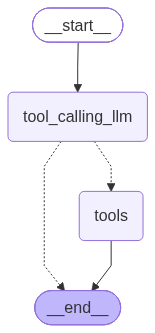

In [20]:
## node definition 
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# build graph

builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#edge

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition,)

builder.add_edge("tools",END)

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))





In [21]:
messages = graph.invoke({"messages":"hi,,i am kavitha"})

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

hi,,i am kavitha
================================== Ai Message ==================================

Hi Kavitha! Nice to meet you. How can I help you today?
